In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import re
import html
import pandas as pd

**READ DATA**

In [ ]:
path = '/content/drive/MyDrive/dataTA/Data_TA/data_TA_1.csv'
df = pd.read_csv(path)
df.head()

,conversation_id_str,created_at,favorite_count,Index,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1871423032138600960,2024-12-24T05:09:54.000Z,645,1,"Aku rela ikut lomba lari keliling dunia, asalk...",1871423032138600960,https://pbs.twimg.com/media/GfihUDibkAAc6xK.jpg,NaN,in,NaN,0,16,72,https://x.com/jevolante_id/status/187142303213...,1850425341938118912,jevolante_id
1,1871065733217808896,2024-12-23T05:30:08.000Z,3131,2,Ini aplikasi lari apalagi sih 😭 baru coba tapi...,1871065733217808896,https://pbs.twimg.com/media/GfdcXi_bsAAKN0D.jpg,NaN,ja,NaN,10,2,645,https://x.com/semangkukuji/status/187106573321...,1726972094074981888,semangkukuji
2,1869329304250949888,2024-12-18T10:30:11.000Z,1137,3,tadi lari pagi niatnya santai malah ketawa sen...,1869329304250949888,https://pbs.twimg.com/media/GfExFZPaIAA3aq-.jpg,NaN,in,NaN,8,60,138,https://x.com/MikazukiArion/status/18693293042...,1620372191287329024,MikazukiArion
3,1866004905602801920,2024-12-09T06:20:12.000Z,472,4,"lagi nyari sepatu lari baru, bingung banget ba...",1866004905602801920,https://pbs.twimg.com/media/GeVhknxW4AALmB3.jpg,NaN,in,NaN,49,50,24,https://x.com/pompomfess/status/18660049056028...,1639968630007030016,pompomfess
4,1871499564848762880,2024-12-24T10:14:01.000Z,1361,5,"lagi pengen ikut event lari luar kota sih, vib...",1871499564848762880,https://pbs.twimg.com/media/GfjmzC4agAEasgn.jpg,NaN,in,NaN,4,42,275,https://x.com/dlayyyyyyyy/status/1871499564848...,1530862213379984896,dlayyyyyyyy


In [ ]:
print(f"✅ Data loaded: {len(df)} tweets")
print(f"   Kolom tersedia: {df.columns.tolist()}\n")

✅ Data loaded: 4890 tweets
   Kolom tersedia: ['conversation_id_str', 'created_at', 'favorite_count', 'Index', 'full_text', 'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location', 'quote_count', 'reply_count', 'retweet_count', 'tweet_url', 'user_id_str', 'username']



In [ ]:
# ─────────────────────────────────────────────
# 2. FILTER TWEET NON-LATIN
#    Alasan: lang tag Twitter tidak reliable untuk data ini.
#    Tweet berbahasa Thai, Jepang, Korea, Arab memiliki
#    karakter non-Latin yang jelas bukan Indo/Inggris.
#    Sebaiknya di-drop berdasarkan deteksi karakter,
#    BUKAN berdasarkan kolom 'lang'.
# ─────────────────────────────────────────────
NON_LATIN_PATTERN = re.compile(
    r'[\u0600-\u06FF'   # Arab
    r'\u3000-\u9FFF'    # CJK (Jepang, Cina)
    r'\uAC00-\uD7AF'    # Korea
    r'\u0E00-\u0E7F]'   # Thai
)

mask_non_latin = df["full_text"].astype(str).str.contains(
    NON_LATIN_PATTERN, regex=True, na=False
)

n_dropped = mask_non_latin.sum()
df_clean = df[~mask_non_latin].copy()

print(f"🗑️  Drop tweet karakter non-Latin: {n_dropped} tweets")
print(f"   Sisa: {len(df_clean)} tweets\n")

🗑️  Drop tweet karakter non-Latin: 207 tweets
   Sisa: 4683 tweets



In [ ]:
# ─────────────────────────────────────────────
# 3. FUNGSI PREPROCESSING UTAMA
# ─────────────────────────────────────────────

def preprocess_tweet(text: str) -> str:
    """
    Pipeline preprocessing ringan untuk tweet berbahasa Indonesia.
    Urutan tahap penting untuk menghindari artefak pembersihan.
    """

    # ── 3a. Decode HTML entities ────────────────────────────────
    # &amp; → &  |  &lt; → <  |  &gt; → >  |  &quot; → "
    # Harus dilakukan SEBELUM cleaning lain agar tidak memengaruhi
    # deteksi pola seperti URL atau mention.
    text = html.unescape(text)

    # ── 3b. Hapus URL ────────────────────────────────────────────
    # Menghapus http/https URLs termasuk t.co (URL shortener Twitter).
    # URL tidak memberi nilai semantik untuk topic modeling.
    text = re.sub(r"https?://\S+", "", text)

    # ── 3c. Hapus mention (@username) ────────────────────────────
    # Mention tidak membawa informasi topik.
    text = re.sub(r"@\w+", "", text)

    # ── 3d. Tangani hashtag ──────────────────────────────────────
    # Strategi: Ambil teksnya, buang simbolnya (#).
    # Alasan: kata dalam hashtag sering relevan dengan topik
    # (misal: #laripagi → "laripagi", #RunningCommunity → "RunningCommunity")
    text = re.sub(r"#(\w+)", r"\1", text)

    # ── 3e. Case folding (lowercase) ─────────────────────────────
    # Dilakukan SETELAH hashtag agar tidak kehilangan penanda
    # CamelCase pada hashtag multi-kata (tidak krusial tapi rapi).
    text = text.lower()

    # ── 3f. Normalisasi angka konteks lari ───────────────────────
    # Pertahankan: 5k, 10k, 21k, 42k, 5km, 10km, half marathon, dll.
    # Pola angka + k/km sudah terjaga karena kita tidak menghapus angka.
    # Tidak perlu aksi khusus, cukup pastikan tidak ter-strip.
    # (Catatan: angka umum juga dipertahankan untuk menjaga konteks)

    # ── 3g. Hapus karakter khusus (minimal) ──────────────────────
    # Yang dihapus:
    #   - Karakter kontrol dan non-printable
    #   - Simbol yang tidak relevan (selain tanda baca umum)
    # Yang DIPERTAHANKAN:
    #   - Angka (termasuk konteks lari: 5k, 10k, 21k)
    #   - Huruf Latin (a-z)
    #   - Spasi
    #   - Tanda baca dasar: . , ! ? - ' " ()
    # Emoji DIHAPUS karena berpotensi membuat embedding tidak stabil
    # pada model multilingual, tetapi opsi ini bisa didiskusikan.
    text = re.sub(
        r"[^\w\s\.\,\!\?\-\'\"\(\)]",  # simpan: kata, spasi, tanda baca dasar
        " ",
        text
    )

    # ── 3h. Normalisasi whitespace ───────────────────────────────
    # Ganti newline, tab, multiple spaces menjadi satu spasi.
    text = re.sub(r"\s+", " ", text)

    # ── 3i. Strip ────────────────────────────────────────────────
    text = text.strip()

    return text

In [ ]:
# ─────────────────────────────────────────────
# 4. TERAPKAN PREPROCESSING
# ─────────────────────────────────────────────
df_clean["clean_text"] = df_clean["full_text"].astype(str).apply(preprocess_tweet)

print("✅ Preprocessing selesai diterapkan\n")


✅ Preprocessing selesai diterapkan



In [ ]:
df_clean

,conversation_id_str,created_at,favorite_count,Index,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,clean_text
0,1871423032138600960,2024-12-24T05:09:54.000Z,645,1,"Aku rela ikut lomba lari keliling dunia, asalk...",1871423032138600960,https://pbs.twimg.com/media/GfihUDibkAAc6xK.jpg,NaN,in,NaN,0,16,72,https://x.com/jevolante_id/status/187142303213...,1850425341938118912,jevolante_id,"aku rela ikut lomba lari keliling dunia, asalk..."
1,1871065733217808896,2024-12-23T05:30:08.000Z,3131,2,Ini aplikasi lari apalagi sih 😭 baru coba tapi...,1871065733217808896,https://pbs.twimg.com/media/GfdcXi_bsAAKN0D.jpg,NaN,ja,NaN,10,2,645,https://x.com/semangkukuji/status/187106573321...,1726972094074981888,semangkukuji,ini aplikasi lari apalagi sih baru coba tapi m...
2,1869329304250949888,2024-12-18T10:30:11.000Z,1137,3,tadi lari pagi niatnya santai malah ketawa sen...,1869329304250949888,https://pbs.twimg.com/media/GfExFZPaIAA3aq-.jpg,NaN,in,NaN,8,60,138,https://x.com/MikazukiArion/status/18693293042...,1620372191287329024,MikazukiArion,tadi lari pagi niatnya santai malah ketawa sen...
3,1866004905602801920,2024-12-09T06:20:12.000Z,472,4,"lagi nyari sepatu lari baru, bingung banget ba...",1866004905602801920,https://pbs.twimg.com/media/GeVhknxW4AALmB3.jpg,NaN,in,NaN,49,50,24,https://x.com/pompomfess/status/18660049056028...,1639968630007030016,pompomfess,"lagi nyari sepatu lari baru, bingung banget ba..."
4,1871499564848762880,2024-12-24T10:14:01.000Z,1361,5,"lagi pengen ikut event lari luar kota sih, vib...",1871499564848762880,https://pbs.twimg.com/media/GfjmzC4agAEasgn.jpg,NaN,in,NaN,4,42,275,https://x.com/dlayyyyyyyy/status/1871499564848...,1530862213379984896,dlayyyyyyyy,"lagi pengen ikut event lari luar kota sih, vib..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4885,2024794591849816064,2026-02-20T10:33:44.000Z,3,4886,"You can’t lose weight at one particular spot, ...",2024794591849816064,NaN,NaN,en,NaN,0,0,0,https://x.com/EzinneOdigbo/status/202479459184...,1629529201731674112,EzinneOdigbo,"you can t lose weight at one particular spot, ..."
4886,2024793585061928960,2026-02-20T10:29:44.000Z,0,4887,The Residential Program at Chellaram Ultra Wel...,2024793585061928960,https://pbs.twimg.com/amplify_video_thumb/2024...,NaN,en,NaN,0,0,0,https://x.com/ChellaramW/status/20247935850619...,1734840515328442112,ChellaramW,the residential program at chellaram ultra wel...
4887,2024787120871677952,2026-02-20T10:04:02.000Z,1,4888,You’re simply training for muscular endurance ...,2024787120871677952,NaN,NaN,en,NaN,0,0,0,https://x.com/fit_iam/status/2024787120871678327,1025125284654342016,fit_iam,you re simply training for muscular endurance ...
4888,2024794543833666048,2026-02-20T10:33:32.000Z,0,4889,The strength of Equity Group Foundation #Equit...,2024794543833666048,https://pbs.twimg.com/media/HBmD5MVXoAAoFRB.jpg,NaN,en,NaN,0,0,1,https://x.com/KenyanFever2/status/202479454383...,1617126092438966016,KenyanFever2,the strength of equity group foundation equity...


In [ ]:
# ─────────────────────────────────────────────
# 5. POST-FILTER: HAPUS HASIL YANG KOSONG / TERLALU PENDEK
#    Beberapa tweet setelah cleaning mungkin menjadi string kosong
#    atau hanya berisi 1-2 karakter sisa (bukan kata bermakna).
#    Ini minimal filtering, bukan berdasarkan jumlah kata asli.
# ─────────────────────────────────────────────
before_postfilter = len(df_clean)

df_clean = df_clean[df_clean["clean_text"].str.len() > 5].copy()
df_clean = df_clean[df_clean["clean_text"].str.strip() != ""].copy()

n_removed_empty = before_postfilter - len(df_clean)
print(f"🗑️  Drop tweet kosong/terlalu pendek setelah cleaning: {n_removed_empty}")
print(f"   Sisa akhir: {len(df_clean)} tweets\n")

🗑️  Drop tweet kosong/terlalu pendek setelah cleaning: 91
   Sisa akhir: 4592 tweets



In [ ]:
# ─────────────────────────────────────────────
# 6. RINGKASAN & SAMPLE HASIL
# ─────────────────────────────────────────────
print("=" * 60)
print("RINGKASAN PREPROCESSING")
print("=" * 60)
print(f"  Total awal           : {len(df):,}")
print(f"  Drop non-Latin       : {n_dropped:,}")
print(f"  Drop kosong (post)   : {n_removed_empty:,}")
print(f"  Total akhir          : {len(df_clean):,}")
print(f"  Data retained        : {len(df_clean)/len(df)*100:.1f}%\n")

print("─" * 60)
print("SAMPLE PERBANDINGAN (5 tweet random)")
print("─" * 60)
sample = df_clean.sample(5, random_state=42)
for i, row in enumerate(sample.itertuples(), 1):
    print(f"\n[{i}] ORIGINAL :\n    {row.full_text[:200]}")
    print(f"    CLEAN    :\n    {row.clean_text[:200]}")

print("\n" + "=" * 60)
print("✅ Preprocessing selesai! Siap untuk BERTopic.")
print("=" * 60)

RINGKASAN PREPROCESSING
  Total awal           : 4,890
  Drop non-Latin       : 207
  Drop kosong (post)   : 91
  Total akhir          : 4,592
  Data retained        : 93.9%

────────────────────────────────────────────────────────────
SAMPLE PERBANDINGAN (5 tweet random)
────────────────────────────────────────────────────────────

[1] ORIGINAL :
    @txtdarisugab Baik olahraga mahal maupun murah, udah jelas rumah ga bakalan kebeli. 🔥

Ya mending olahraga mahal aja sekalian (padel, nge-gym, lari pakai sepatu mahal, sepedaan pakai sepeda mahal, dsb
    CLEAN    :
    baik olahraga mahal maupun murah, udah jelas rumah ga bakalan kebeli. ya mending olahraga mahal aja sekalian (padel, nge-gym, lari pakai sepatu mahal, sepedaan pakai sepeda mahal, dsb.). setidaknya ma

[2] ORIGINAL :
    Sepatu Olahraga Lari Sneakers Hoka One Carbon Clifton 9 X2 Running Shoes 100% - Size 37-41 - Outdoor Unisex Unisex sepatu  lari https://t.co/4GkpY31UZI
    CLEAN    :
    sepatu olahraga lari sneakers hoka

In [ ]:
# Ambil kolom clean_text saja
df = df_clean['clean_text'].astype(str)
print("Jumlah tweet:", len(df))
df.head()

Jumlah tweet: 4592


,clean_text
0,"aku rela ikut lomba lari keliling dunia, asalk..."
1,ini aplikasi lari apalagi sih baru coba tapi m...
2,tadi lari pagi niatnya santai malah ketawa sen...
3,"lagi nyari sepatu lari baru, bingung banget ba..."
4,"lagi pengen ikut event lari luar kota sih, vib..."


In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 11.0 MB/s eta 0:00:00


In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 23.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=f659667a31bb6f258985174c52505919cb816a40e7e544846c21e4bc3343307a
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
# ────────────────────────────────────────────────────────────────
# [1] IMPORT LIBRARY
# ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from langdetect import detect, LangDetectException
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer

In [ ]:
# Ambil kolom clean_text sebagai input model
docs = df_clean["clean_text"].astype(str).tolist()

print("=" * 55)
print("DATA YANG DIGUNAKAN")
print("=" * 55)
print(f"  Jumlah tweet  : {len(docs):,}")
print(f"  Contoh dokumen:")
for i, d in enumerate(docs[:3], 1):
    print(f"  [{i}] {d[:90]}...")
print()

DATA YANG DIGUNAKAN
  Jumlah tweet  : 4,592
  Contoh dokumen:
  [1] aku rela ikut lomba lari keliling dunia, asalkan engkau yang menjadi garis finishnya. gomb...
  [2] ini aplikasi lari apalagi sih baru coba tapi masih bingung bacanya, pace nya kok naik turu...
  [3] tadi lari pagi niatnya santai malah ketawa sendiri ngos2an badan gue kenapa sih...



In [ ]:
docs

['aku rela ikut lomba lari keliling dunia, asalkan engkau yang menjadi garis finishnya. gombalangaul cintaku sayangku cinta love wow cantik maugakjadipacarku jkt48cantik fyp',
 'ini aplikasi lari apalagi sih baru coba tapi masih bingung bacanya, pace nya kok naik turun gini',
 'tadi lari pagi niatnya santai malah ketawa sendiri ngos2an badan gue kenapa sih',
 'lagi nyari sepatu lari baru, bingung banget banyak pilihan ada yg pernah pake yang enak buat daily run ga?',
 'lagi pengen ikut event lari luar kota sih, vibes nya beda banget pasti apalagi kalo ramean gitu',
 'lagi nyari challenge biar konsisten lari, soalnya akhir2 ini gampang kendor butuh sesuatu yg bikin semangat lagi',
 'makasih banget temen2 lari gue tahun ini, dari yang awalnya males sampe sekarang malah nagih',
 'besok mau coba long run pagi, semoga ga kebangun kesiangan lagi',
 'abis lari enaknya minum coklat panas apa dingin ya kadang bingung sendiri milihnya wkwk',
 'event lari akhir tahun makin banyak ya, jadi pengen 

In [ ]:
# ────────────────────────────────────────────────────────────────
# [2b] FILTER BAHASA — PERTAHANKAN INDONESIA & INGGRIS SAJA
# ────────────────────────────────────────────────────────────────
# Mengapa perlu dilakukan di sini (bukan hanya di preprocessing)?
#   Preprocessing sebelumnya memfilter karakter non-Latin, namun
#   tweet Portugis berbasis Latin (huruf sama dengan Indonesia)
#   tetap lolos. langdetect mendeteksi berdasarkan pola statistik
#   bahasa, sehingga lebih akurat untuk kasus ini.
#
# Bahasa yang dipertahankan:
#   "id" → Indonesia
#   "en" → Inggris
#
# Catatan: langdetect bisa salah deteksi untuk tweet sangat pendek
#   (< 5 kata). Oleh karena itu, tweet pendek dipertahankan secara
#   default (fallback=True) agar tidak banyak data yang terbuang.

# ── FIX: seed langdetect agar hasil konsisten setiap run ──
from langdetect import DetectorFactory
DetectorFactory.seed = 0   # ← tambahkan ini

ALLOWED_LANGS = {"id", "en"}

def is_allowed_language(text: str) -> bool:
    """
    Deteksi bahasa teks. Kembalikan True jika Indonesia atau Inggris.
    Tweet terlalu pendek (< 4 kata) dipertahankan untuk menghindari
    false positive dari langdetect pada teks sangat singkat.
    """
    if len(text.split()) < 4:
        return True  # terlalu pendek untuk deteksi akurat → pertahankan
    try:
        return detect(text) in ALLOWED_LANGS
    except LangDetectException:
        return True  # jika gagal deteksi → pertahankan

print("Menjalankan filter bahasa (Indonesia & Inggris)...")

n_before_langfilter = len(df_clean)
lang_mask = df_clean["clean_text"].astype(str).apply(is_allowed_language)
df_clean  = df_clean[lang_mask].reset_index(drop=True)

n_after_langfilter  = len(df_clean)
n_dropped_lang      = n_before_langfilter - n_after_langfilter

print(f"  Sebelum filter : {n_before_langfilter:,} tweet")
print(f"  Sesudah filter : {n_after_langfilter:,} tweet")
print(f"  Dihapus        : {n_dropped_lang:,} tweet (bahasa non-Indo/Inggris)")
print()

# Update docs dengan data yang sudah difilter
docs = df_clean["clean_text"].astype(str).tolist()

Menjalankan filter bahasa (Indonesia & Inggris)...
  Sebelum filter : 4,592 tweet
  Sesudah filter : 4,147 tweet
  Dihapus        : 445 tweet (bahasa non-Indo/Inggris)



In [ ]:
# ────────────────────────────────────────────────────────────────
# [3] EMBEDDING MODEL (SBERT)
# ────────────────────────────────────────────────────────────────
# Model: paraphrase-multilingual-MiniLM-L12-v2
#   - Mendukung 50+ bahasa termasuk Indonesia dan Inggris
#   - Ringan (~118MB) dan cepat, cocok untuk eksperimen di Colab
#   - Menghasilkan embedding 384 dimensi per kalimat
#   - Dilatih dengan paraphrase objective → baik untuk menangkap
#     kemiripan makna antar tweet

print("Memuat embedding model...")
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
print("  ✅ Embedding model siap\n")

Memuat embedding model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  ✅ Embedding model siap



In [ ]:
# ────────────────────────────────────────────────────────────────
# [4] UMAP — DIMENSIONALITY REDUCTION
# ────────────────────────────────────────────────────────────────
# Fungsi: Mereduksi embedding 384-dimensi → 5-dimensi
#         agar HDBSCAN bisa melakukan clustering lebih efektif.
#
# Parameter:
#   n_neighbors = 15  → keseimbangan struktur lokal & global
#                       (cocok untuk ~4.500 dokumen)
#   n_components = 5  → dimensi output, standar untuk BERTopic
#   min_dist     = 0.0 → titik dalam cluster dirapatkan
#                        (optimal untuk clustering, bukan visualisasi)
#   metric       = "cosine" → sesuai dengan karakteristik
#                             sentence embedding (cosine similarity)
#   random_state = 42  → reprodusibilitas hasil

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

In [ ]:

# ────────────────────────────────────────────────────────────────
# [5] HDBSCAN — CLUSTERING
# ────────────────────────────────────────────────────────────────
# Fungsi: Mengelompokkan embedding berdasarkan kepadatan titik.
#         Dokumen yang tidak masuk cluster manapun → Topic -1 (outlier)
#
# Parameter:
#   min_cluster_size = 15   → ukuran minimum cluster yang valid
#                             (cluster < 15 dokumen akan di-dissolve)
#   min_samples = 5         → lebih kecil dari min_cluster_size →
#                             mengurangi outlier (cluster lebih inklusif)
#   cluster_selection_method = "leaf" → menghasilkan cluster yang
#                             lebih granular dan lebih sedikit outlier
#                             dibanding default "eom"
#   prediction_data = True  → WAJIB diaktifkan untuk mendukung
#                             reduce_outliers() pada tahap post-processing

hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    cluster_selection_method="eom",
    prediction_data=True
)

In [ ]:
# ────────────────────────────────────────────────────────────────
# [6] VECTORIZER — CountVectorizer CUSTOM
# ────────────────────────────────────────────────────────────────
# Fungsi: Mengubah dokumen dalam setiap topik menjadi representasi
#         berbasis frekuensi kata untuk perhitungan c-TF-IDF.
#
# Parameter:
#   ngram_range = (1, 2) → menangkap unigram dan bigram
#                          (misal: "lari" dan "lari pagi")
#   min_df = 3           → abaikan kata yang muncul < 3 kali
#                          (mengurangi noise dari typo/kata unik)
#   stop_words           → custom stopword bahasa Indonesia
#                          (penting karena tidak ada stopword Indo
#                          bawaan di scikit-learn)

# ── Custom Stopword Bahasa Indonesia ────────────────────────────
# Mencakup:
#   - Kata fungsi umum (yang, dan, di, ke, dari, ...)
#   - Kata ganti & kata sapaan (gue, aku, kamu, lu, ...)
#   - Filler & interjeksi Twitter (wkwk, haha, sih, deh, ...)
#   - Kata penghubung & preposisi

STOPWORDS_ID = [
    # Kata fungsi dasar
    "yang", "dan", "di", "ke", "dari", "dengan", "ini", "itu",
    "atau", "tapi", "juga", "untuk", "pada", "adalah", "dalam",
    "tidak", "bisa", "ada", "sudah", "akan", "bisa", "karena",
    "kalau", "kalau", "jadi", "seperti", "lebih", "aja", "saja",
    "nya", "pun", "nih", "tuh", "lah", "kah", "deh", "sih",
    "dong", "kok", "kan", "yah", "ya", "ga", "gak", "ngga",
    "nggak", "enggak", "udah", "udah", "udh", "dah", "masih",
    "mau", "buat", "sama", "kalo", "gimana", "banget", "bgt",
    "banget", "abis", "habis", "kayak", "kayaknya", "kaya",
    # Kata ganti & sapaan
    "gue", "gw", "aku", "ane", "saya", "kamu", "lu", "lo",
    "kita", "kami", "dia", "mereka", "kalian",
    # Filler & interjeksi Twitter
    "wkwk", "wkwkwk", "haha", "hehe", "hihi", "wah", "wow",
    "yuk", "yuk", "ayo", "ah", "oh", "eh", "ih", "duh",
    "aduh", "waduh", "anjir", "anjay", "astaga",
    # Kata keterangan waktu
    "hari", "pagi", "siang", "sore", "malam", "minggu",
    "bulan", "tahun", "kemarin", "besok", "sekarang", "tadi",
    "nanti", "lagi", "lagi", "sdh", "blm", "belum",
    # Kata umum lainnya
    "jalan", "pergi", "balik", "balik", "balik", "tetap",
    "terus", "mulai", "selesai", "sampai", "semua", "banyak",
    "satu", "dua", "tiga", "pertama", "kedua", "pake", "pakai",
    "bikin", "buat", "kasih", "dapat", "dapet", "bilang",
    "beli", "mau", "pengen", "pengen", "ingin", "coba", "cobain",
]

vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    stop_words=STOPWORDS_ID
)

In [ ]:

# ────────────────────────────────────────────────────────────────
# [7] c-TF-IDF
# ────────────────────────────────────────────────────────────────
# Fungsi: Versi c-TF-IDF (class-based TF-IDF) milik BERTopic.
#         Menghitung kata yang paling representatif untuk setiap
#         topik dibanding topik-topik lain (bukan per dokumen).
#
# reduce_frequent_words = True → mengurangi dominasi kata yang
#   sangat sering muncul di semua topik (mirip IDF lebih agresif)

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)


In [ ]:
# ────────────────────────────────────────────────────────────────
# [8] REPRESENTATION MODEL
# ────────────────────────────────────────────────────────────────
# Fungsi: Memperbaiki label kata topik menggunakan pendekatan
#         berbasis embedding (bukan hanya frekuensi).
#
# KeyBERTInspired:
#   - Memilih kata yang embedding-nya paling dekat dengan
#     centroid embedding dokumen dalam topik
#   - Menghasilkan kata kunci yang lebih semantically meaningful
#     dibanding c-TF-IDF murni
#   - Berguna untuk data slang karena menghindari kata slang
#     berfrekuensi tinggi yang tidak bermakna

representation_model = KeyBERTInspired()

In [ ]:
# ────────────────────────────────────────────────────────────────
# [9] INISIALISASI & TRAINING BERTOPIC
# ────────────────────────────────────────────────────────────────
print("Menginisialisasi BERTopic...")

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    representation_model=representation_model,
    language="multilingual",
    calculate_probabilities=True,  # diperlukan untuk reduce_outliers
    verbose=True
)

print("\nMemulai training BERTopic...")
topics, probs = topic_model.fit_transform(docs)
print("\n✅ Training selesai!\n")

2026-05-03 07:21:55,587 - BERTopic - Embedding - Transforming documents to embeddings.


Menginisialisasi BERTopic...

Memulai training BERTopic...


Batches:   0%|          | 0/130 [00:00<?, ?it/s]

2026-05-03 07:24:45,296 - BERTopic - Embedding - Completed ✓
2026-05-03 07:24:45,298 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-03 07:25:24,336 - BERTopic - Dimensionality - Completed ✓
2026-05-03 07:25:24,338 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 07:25:25,169 - BERTopic - Cluster - Completed ✓
2026-05-03 07:25:25,176 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 07:25:41,837 - BERTopic - Representation - Completed ✓



✅ Training selesai!



In [ ]:
# ────────────────────────────────────────────────────────────────
# [10] HASIL AWAL — SEBELUM REDUCE OUTLIERS
# ────────────────────────────────────────────────────────────────
topic_counts = pd.Series(topics)
n_outlier_before = (topic_counts == -1).sum()
n_topics_before  = topic_model.get_topic_info().shape[0] - 1  # exclude -1

print("=" * 55)
print("HASIL AWAL (sebelum reduce outliers)")
print("=" * 55)
print(f"  Jumlah topik terbentuk : {n_topics_before}")
print(f"  Jumlah outlier (Topic -1): {n_outlier_before} "
      f"({n_outlier_before/len(docs)*100:.1f}%)\n")

print("─" * 55)
print("5 TOPIK TERATAS (sebelum reduce outliers)")
print("─" * 55)
topic_info = topic_model.get_topic_info()
top5 = topic_info[topic_info["Topic"] != -1].head(5)

for _, row in top5.iterrows():
    topic_id    = row["Topic"]
    topic_count = row["Count"]
    top_words   = topic_model.get_topic(topic_id)
    words_str   = ", ".join([w for w, _ in top_words[:8]])
    print(f"  Topik {topic_id:>3} ({topic_count:>4} dok) → {words_str}")

print()

HASIL AWAL (sebelum reduce outliers)
  Jumlah topik terbentuk : 48
  Jumlah outlier (Topic -1): 1599 (38.6%)

───────────────────────────────────────────────────────
5 TOPIK TERATAS (sebelum reduce outliers)
───────────────────────────────────────────────────────
  Topik   0 ( 288 dok) → ajang lari, fun run, lomba lari, adadikompas, run, siap, lomba, semarang
  Topik   1 ( 261 dok) → running, lari sepatu, gara, sepatu lari, gel, empuk, evo, sepatu running
  Topik   2 ( 251 dok) → lari capek, lari sambil, lari malah, lari biar, lari jam, diajak lari, harusnya lari, lari santai
  Topik   3 ( 178 dok) → lari dulu, termasuk lari, lari ikut, ikutan lari, lari sampe, lari tp, lari awalnya, lari mah
  Topik   4 ( 107 dok) → jam lari, akhirnya lari, saat lari, lari 5km, trail run, lari 3km, trail running, tempo run



In [ ]:
# ────────────────────────────────────────────────────────────────
# [11] POST-PROCESSING — REDUCE OUTLIERS (TWO-PASS) - "EOM"
# ────────────────────────────────────────────────────────────────
# Menggunakan dua strategi secara berurutan:
#
# Pass 1 — strategy="c-tf-idf", threshold=0.1
#   Cara kerja: Menghitung kemiripan representasi c-TF-IDF dokumen
#   outlier dengan c-TF-IDF setiap topik.
#   Threshold 0.1 (longgar) → lebih banyak outlier dipindahkan.
#   Cocok untuk data tweet pendek yang skor kemiripannya memang
#   secara alami rendah.
#
# Pass 2 — strategy="embeddings", threshold=0.5
#   Cara kerja: Menghitung cosine similarity embedding dokumen
#   outlier (yang masih tersisa setelah Pass 1) dengan centroid
#   embedding setiap topik.
#   Lebih akurat secara semantik dibanding c-TF-IDF, namun lebih
#   lambat. Digunakan sebagai refinement untuk sisa outlier.

print("Menjalankan reduce_outliers — Pass 1 (c-tf-idf, threshold=0.1)...")

topics_pass1 = topic_model.reduce_outliers(
    docs,
    topics,
    strategy="c-tf-idf",
    threshold=0.1
)

n_outlier_pass1 = sum(t == -1 for t in topics_pass1)
print(f"  Outlier awal   : {n_outlier_before:,} ({n_outlier_before/len(docs)*100:.1f}%)")
print(f"  Setelah Pass 1 : {n_outlier_pass1:,} ({n_outlier_pass1/len(docs)*100:.1f}%)")
print(f"  Dipindahkan    : {n_outlier_before - n_outlier_pass1:,} dokumen\n")

print("Menjalankan reduce_outliers — Pass 2 (embeddings, threshold=0.5)...")

topics_pass2 = topic_model.reduce_outliers(
    docs,
    topics_pass1,
    strategy="embeddings",
    threshold=0.5
)

n_outlier_pass2 = sum(t == -1 for t in topics_pass2)
print(f"  Setelah Pass 1 : {n_outlier_pass1:,} ({n_outlier_pass1/len(docs)*100:.1f}%)")
print(f"  Setelah Pass 2 : {n_outlier_pass2:,} ({n_outlier_pass2/len(docs)*100:.1f}%)")
print(f"  Dipindahkan    : {n_outlier_pass1 - n_outlier_pass2:,} dokumen\n")

# Gunakan hasil Pass 2 sebagai topik final
new_topics = topics_pass2

# Update model dengan topik baru hasil two-pass reduce_outliers
topic_model.update_topics(
    docs,
    topics=new_topics,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model
)

print("=" * 55)
print("RINGKASAN REDUCE OUTLIERS")
print("=" * 55)
print(f"  Outlier awal          : {n_outlier_before:,} ({n_outlier_before/len(docs)*100:.1f}%)")
print(f"  Setelah Pass 1 (c-tf) : {n_outlier_pass1:,} ({n_outlier_pass1/len(docs)*100:.1f}%)")
print(f"  Setelah Pass 2 (emb)  : {n_outlier_pass2:,} ({n_outlier_pass2/len(docs)*100:.1f}%)")
print(f"  Total dipindahkan     : {n_outlier_before - n_outlier_pass2:,} dokumen")
print()

Menjalankan reduce_outliers — Pass 1 (c-tf-idf, threshold=0.1)...
  Outlier awal   : 1,599 (38.6%)
  Setelah Pass 1 : 872 (21.0%)
  Dipindahkan    : 727 dokumen

Menjalankan reduce_outliers — Pass 2 (embeddings, threshold=0.5)...


2026-05-03 07:27:15,098 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


  Setelah Pass 1 : 872 (21.0%)
  Setelah Pass 2 : 109 (2.6%)
  Dipindahkan    : 763 dokumen

RINGKASAN REDUCE OUTLIERS
  Outlier awal          : 1,599 (38.6%)
  Setelah Pass 1 (c-tf) : 872 (21.0%)
  Setelah Pass 2 (emb)  : 109 (2.6%)
  Total dipindahkan     : 1,490 dokumen



In [ ]:
# ────────────────────────────────────────────────────────────────
# [12] POST-PROCESSING — REDUCE TOPICS
# ────────────────────────────────────────────────────────────────
# Fungsi: Menggabungkan topik-topik yang representasi c-TF-IDF-nya
#         paling mirip satu sama lain, hingga mencapai nr_topics.
#
# nr_topics = 20 → target jumlah topik akhir.
#   Dipilih secara manual berdasarkan pertimbangan peneliti,
#   lebih mudah dijelaskan secara ilmiah dibanding "auto".
#
# Mengapa diperlukan?
#   Hasil HDBSCAN sering menghasilkan topik granular yang redundan
#   (misal: beberapa topik berbeda dengan kata kunci serupa
#   "olahraga lari"). reduce_topics menggabungkan topik-topik ini
#   menjadi representasi yang lebih bersih dan interpretatif.

n_topics_before_reduce = topic_model.get_topic_info().shape[0] - 1

print("Menjalankan reduce_topics (nr_topics=20)...")

topic_model.reduce_topics(docs, nr_topics=20)

n_topics_after_reduce = topic_model.get_topic_info().shape[0] - 1

# Ambil assignment topik final setelah reduce_topics
final_topics = topic_model.topics_

print(f"  Topik sebelum reduce  : {n_topics_before_reduce}")
print(f"  Topik sesudah reduce  : {n_topics_after_reduce}")
print(f"  Topik digabungkan     : {n_topics_before_reduce - n_topics_after_reduce}")
print()

2026-05-03 07:28:17,406 - BERTopic - Topic reduction - Reducing number of topics
2026-05-03 07:28:17,449 - BERTopic - Representation - Fine-tuning topics using representation models.


Menjalankan reduce_topics (nr_topics=20)...


2026-05-03 07:28:29,315 - BERTopic - Representation - Completed ✓
2026-05-03 07:28:29,321 - BERTopic - Topic reduction - Reduced number of topics from 49 to 20


  Topik sebelum reduce  : 48
  Topik sesudah reduce  : 19
  Topik digabungkan     : 29



In [ ]:
# ────────────────────────────────────────────────────────────────
# [13] TAMPILKAN TOPIK FINAL
# ────────────────────────────────────────────────────────────────
print("─" * 55)
print("SEMUA TOPIK FINAL (setelah reduce outliers + reduce topics)")
print("─" * 55)

topic_info_final = topic_model.get_topic_info()
topics_only = topic_info_final[topic_info_final["Topic"] != -1]

for _, row in topics_only.iterrows():
    topic_id    = row["Topic"]
    topic_count = row["Count"]
    top_words   = topic_model.get_topic(topic_id)
    words_str   = ", ".join([w for w, _ in top_words[:8]])
    print(f"  Topik {topic_id:>3} ({topic_count:>4} dok) → {words_str}")

outlier_row = topic_info_final[topic_info_final["Topic"] == -1]
n_outlier_final = outlier_row["Count"].values[0] if len(outlier_row) > 0 else 0

print()
print(f"  [Outlier / Topic -1]: {n_outlier_final:,} dok "
      f"({n_outlier_final/len(docs)*100:.1f}%)")

print()
print("=" * 55)
print("✅ Pipeline BERTopic selesai!")
print("=" * 55)

───────────────────────────────────────────────────────
SEMUA TOPIK FINAL (setelah reduce outliers + reduce topics)
───────────────────────────────────────────────────────
  Topik   0 (1656 dok) → lari olahraga, olahraga lari, lari lari, run, suka olahraga, marathon, olahraga, latihan
  Topik   1 ( 471 dok) → dibilang fomo, yg fomo, orang fomo, lari fomo, karna fomo, fomonya, fomo, fomo doang
  Topik   2 ( 360 dok) → sepatu olahraga, rekomendasi sepatu, sepatu, shoes, sepatu yg, sepatunya, sepatu lari, shoe
  Topik   3 ( 303 dok) → run 2025, fun run, 2025, run, 2026, ajang lari, event lari, lomba lari
  Topik   4 ( 303 dok) → strength training, workout, latihan, exercise, endurance, olahraga rutin, training, strength
  Topik   5 ( 220 dok) → lari biar, terakhir lari, lari liat, kepikiran lari, malah kepikiran, panjang malah, ketinggalan, mikir lari
  Topik   6 ( 165 dok) → lari harga, sepeda lari, running belt, joging, lari jogging, jogging lari, jogging, futsal
  Topik   7 ( 149 dok) 

In [ ]:
# ================================================================
# EVALUASI MODEL BERTOPIC — ANALISIS PERCAKAPAN OLAHRAGA LARI
# ================================================================
# Metrik evaluasi:
#   1. Topic Coherence (C_v) — via Gensim
#   2. Topic Diversity        — unique words ratio
# Visualisasi:
#   3. Bar chart distribusi dokumen per topik
#   4. Top words per topik (horizontal bar chart)
#   5. Intertopic Distance Map (BERTopic built-in)
# ================================================================

In [ ]:
# ────────────────────────────────────────────────────────────────
# [0] INSTALASI (jalankan sekali di Colab)
# ────────────────────────────────────────────────────────────────
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.5 MB/s eta 0:00:00


In [ ]:

# ────────────────────────────────────────────────────────────────
# [1] IMPORT LIBRARY
# ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

In [ ]:
# ────────────────────────────────────────────────────────────────
# [2] PERSIAPAN DATA
# ────────────────────────────────────────────────────────────────
# Pastikan variabel berikut tersedia dari pipeline BERTopic:
#   topic_model  → model BERTopic yang sudah di-fit
#   docs         → list dokumen (clean_text) setelah filtering bahasa
#   final_topics → list assignment topik per dokumen (hasil reduce_topics)
#
# Jika evaluasi dijalankan di file terpisah, load ulang dari CSV:
# ----------------------------------------------------------------
# df = pd.read_csv("hasil_bertopic.csv")
# docs         = df["clean_text"].astype(str).tolist()
# final_topics = df["topic_final"].tolist()
# ----------------------------------------------------------------

# Ambil hanya topik yang VALID (exclude Topic -1 dan topik noise)
# Sesuaikan NOISE_TOPICS berdasarkan inspeksi manual topik Anda.
# Contoh dari hasil model: topik 10, 11, 13, 17, 18 → tidak relevan

NOISE_TOPICS = {9, 10, 11, 17, 18}   # ← sesuaikan jika perlu

topic_info = topic_model.get_topic_info()
valid_topic_ids = [
    t for t in topic_info["Topic"].tolist()
    if t != -1 and t not in NOISE_TOPICS
]

print("=" * 58)
print("PERSIAPAN EVALUASI")
print("=" * 58)
print(f"  Total topik model      : {len(topic_info) - 1}")
print(f"  Topik dikecualikan     : {sorted(NOISE_TOPICS)} (noise/tidak relevan)")
print(f"  Topik dievaluasi       : {len(valid_topic_ids)}")
print()

PERSIAPAN EVALUASI
  Total topik model      : 19
  Topik dikecualikan     : [9, 10, 11, 17, 18] (noise/tidak relevan)
  Topik dievaluasi       : 14



In [ ]:
# ── CEK VARIABEL SEBELUM HITUNG COHERENCE ──
print("topic_model  :", type(topic_model))
print("docs         :", type(docs), "| len:", len(docs))
print("valid_topic_ids :", valid_topic_ids)
print("topics_words :", len(topics_words) if 'topics_words' in dir() else "BELUM ADA")

topic_model  : <class 'bertopic._bertopic.BERTopic'>
docs         : <class 'list'> | len: 4147
valid_topic_ids : [0, 1, 2, 3, 4, 5, 6, 7, 8, 12, 13, 14, 15, 16]
topics_words : BELUM ADA


In [ ]:
# ────────────────────────────────────────────────────────────────
# [3] TOPIC COHERENCE — C_v (via Gensim)
# ────────────────────────────────────────────────────────────────
# C_v mengukur seberapa sering kata-kata dalam satu topik
# muncul bersama (co-occur) dalam dokumen nyata.
#
# Nilai C_v berkisar 0–1:
#   > 0.70 → sangat baik
#   0.50–0.70 → baik / cukup (umum untuk data Twitter)
#   < 0.50 → kurang koheren
#
# Alur perhitungan:
#   1. Tokenisasi dokumen → list of list of words
#   2. Bangun Gensim Dictionary dari corpus
#   3. Ambil top-N words dari setiap topik BERTopic
#   4. Hitung C_v menggunakan CoherenceModel Gensim

TOP_N_WORDS = 10   # jumlah kata teratas per topik untuk evaluasi

# ── 3a. Tokenisasi dokumen ───────────────────────────────────────
tokenized_docs = [doc.split() for doc in docs]

# ── 3b. Bangun Dictionary Gensim ────────────────────────────────
dictionary = Dictionary(tokenized_docs)

# ── 3c. Ambil top words dari setiap topik yang valid ────────────
topics_words = []
for topic_id in valid_topic_ids:
    words = [word for word, _ in topic_model.get_topic(topic_id)[:TOP_N_WORDS]]
    topics_words.append(words)

# ── 3d. Hitung Coherence C_v ────────────────────────────────────
coherence_model = CoherenceModel(
    topics=topics_words,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence="c_v"
)

coherence_score = coherence_model.get_coherence()

# Skor per topik (untuk analisis detail)
coherence_per_topic = coherence_model.get_coherence_per_topic()

print("=" * 58)
print("TOPIC COHERENCE (C_v)")
print("=" * 58)
print(f"  Coherence Score (C_v) : {coherence_score:.4f}")

if coherence_score >= 0.70:
    interpretasi_cv = "Sangat Baik ✅"
elif coherence_score >= 0.50:
    interpretasi_cv = "Baik / Cukup ✅"
else:
    interpretasi_cv = "Kurang Koheren ⚠️"

print(f"  Interpretasi          : {interpretasi_cv}")
print()
print("  Coherence per topik:")
print(f"  {'Topik':<10} {'C_v':>8}   {'Top Words (5 pertama)'}")
print("  " + "-" * 55)
for topic_id, cv in zip(valid_topic_ids, coherence_per_topic):
    words_preview = ", ".join(topics_words[valid_topic_ids.index(topic_id)][:5])
    print(f"  Topik {topic_id:<4}   {cv:>6.4f}   {words_preview}")
print()

TOPIC COHERENCE (C_v)
  Coherence Score (C_v) : 0.5612
  Interpretasi          : Baik / Cukup ✅

  Coherence per topik:
  Topik           C_v   Top Words (5 pertama)
  -------------------------------------------------------
  Topik 0      0.5142   lari olahraga, olahraga lari, lari lari, run, suka olahraga
  Topik 1      0.8692   dibilang fomo, yg fomo, orang fomo, lari fomo, karna fomo
  Topik 2      0.4701   sepatu olahraga, rekomendasi sepatu, sepatu, shoes, sepatu yg
  Topik 3      0.4435   run 2025, fun run, 2025, run, 2026
  Topik 4      0.4967   strength training, workout, latihan, exercise, endurance
  Topik 5      0.1855   lari biar, terakhir lari, lari liat, kepikiran lari, malah kepikiran
  Topik 6      0.9038   lari harga, sepeda lari, running belt, joging, lari jogging
  Topik 7      0.4034   semangat, kata, hehehe, tak, lancar
  Topik 8      1.0000   malah kepikiran, kepikiran lari, malah keinget, random, lari random
  Topik 12     0.0402   lari makanya, lari keliling, la

In [ ]:
# ────────────────────────────────────────────────────────────────
# [4] TOPIC DIVERSITY
# ────────────────────────────────────────────────────────────────
# Definisi standar (Dieng et al., 2020):
#   TD = jumlah unique words di seluruh topik
#        ─────────────────────────────────────
#        total words (N_topik × TOP_N_WORDS)
#
# Nilai TD berkisar 0–1:
#   > 0.70 → diversitas tinggi (topik-topik tidak redundan)
#   0.40–0.70 → diversitas sedang
#   < 0.40 → banyak kata yang tumpang tindih antar topik
#
# Catatan: TD tidak selalu harus setinggi mungkin — untuk domain
# spesifik (seperti lari), wajar jika ada kata berulang seperti
# "lari" atau "olahraga" yang muncul di beberapa topik.

all_words   = [w for words in topics_words for w in words]
unique_words = set(all_words)

topic_diversity = len(unique_words) / len(all_words)

print("=" * 58)
print("TOPIC DIVERSITY")
print("=" * 58)
print(f"  Total words (semua topik) : {len(all_words)}")
print(f"  Unique words              : {len(unique_words)}")
print(f"  Topic Diversity Score     : {topic_diversity:.4f}")

if topic_diversity >= 0.70:
    interpretasi_td = "Diversitas Tinggi ✅"
elif topic_diversity >= 0.40:
    interpretasi_td = "Diversitas Sedang ✅"
else:
    interpretasi_td = "Diversitas Rendah ⚠️ (banyak kata tumpang tindih)"

print(f"  Interpretasi              : {interpretasi_td}")
print()

TOPIC DIVERSITY
  Total words (semua topik) : 140
  Unique words              : 123
  Topic Diversity Score     : 0.8786
  Interpretasi              : Diversitas Tinggi ✅



In [ ]:
# ────────────────────────────────────────────────────────────────
# [5] RINGKASAN EVALUASI
# ────────────────────────────────────────────────────────────────
print("=" * 58)
print("RINGKASAN EVALUASI MODEL BERTOPIC")
print("=" * 58)
print(f"  Jumlah topik dievaluasi  : {len(valid_topic_ids)}")
print(f"  Topic Coherence (C_v)    : {coherence_score:.4f}  → {interpretasi_cv}")
print(f"  Topic Diversity          : {topic_diversity:.4f}  → {interpretasi_td}")
print()
print("  Panduan membaca untuk skripsi:")
print("  • C_v mengukur kualitas internal topik — seberapa 'masuk akal'")
print("    kata-kata dalam satu topik secara linguistik.")
print("  • Topic Diversity mengukur keberagaman antar topik — seberapa")
print("    berbeda konten setiap topik satu sama lain.")
print("  • Kedua metrik idealnya dilaporkan bersama, karena model bisa")
print("    memiliki C_v tinggi namun diversitas rendah (topik redundan),")
print("    atau sebaliknya.")
print("=" * 58)
print()


RINGKASAN EVALUASI MODEL BERTOPIC
  Jumlah topik dievaluasi  : 14
  Topic Coherence (C_v)    : 0.5612  → Baik / Cukup ✅
  Topic Diversity          : 0.8786  → Diversitas Tinggi ✅

  Panduan membaca untuk skripsi:
  • C_v mengukur kualitas internal topik — seberapa 'masuk akal'
    kata-kata dalam satu topik secara linguistik.
  • Topic Diversity mengukur keberagaman antar topik — seberapa
    berbeda konten setiap topik satu sama lain.
  • Kedua metrik idealnya dilaporkan bersama, karena model bisa
    memiliki C_v tinggi namun diversitas rendah (topik redundan),
    atau sebaliknya.



In [ ]:
# ════════════════════════════════════════════════════════════════
# [6] VISUALISASI
# ════════════════════════════════════════════════════════════════

# Ambil data topik untuk visualisasi (hanya topik valid)
topic_info_valid = topic_info[
    (topic_info["Topic"] != -1) &
    (~topic_info["Topic"].isin(NOISE_TOPICS))
].copy().sort_values("Topic")

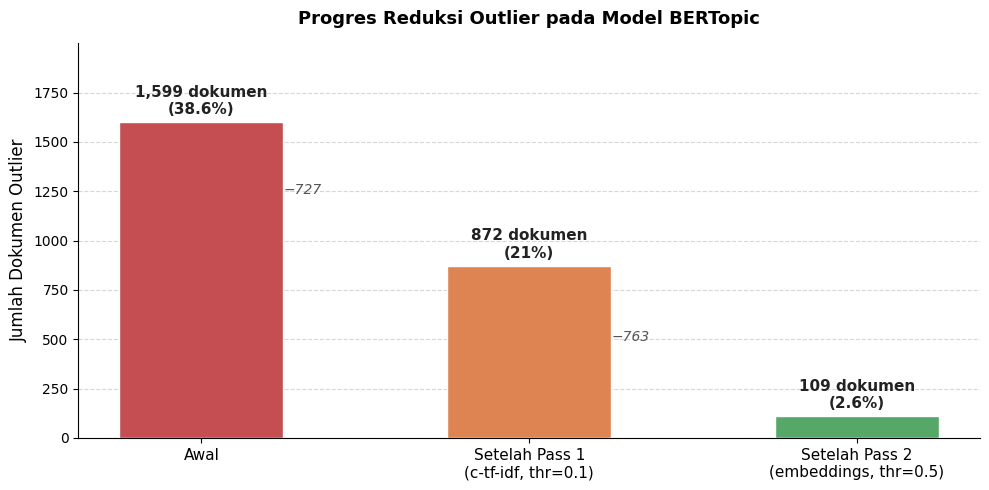

✅ Disimpan: gambar_progres_outlier.png


In [ ]:
# ════════════════════════════════════════════════════════════════
# GAMBAR 1 — Progres Reduksi Outlier
# Posisi skripsi: Setelah Tabel 4.15
# ════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Data reduksi outlier (hardcoded dari hasil model) ---
stages       = ["Awal", "Setelah Pass 1\n(c-tf-idf, thr=0.1)", "Setelah Pass 2\n(embeddings, thr=0.5)"]
outlier_vals = [1599, 872, 109]
pct_vals     = [38.6, 21, 2.6]
bar_colors   = ["#C44E52", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(stages, outlier_vals, color=bar_colors,
              edgecolor="white", width=0.5, zorder=3)

# Label jumlah dokumen di atas bar
for bar, val, pct in zip(bars, outlier_vals, pct_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 25,
            f"{val:,} dokumen\n({pct}%)",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold", color="#222222")

# Anotasi panah penurunan
for i in range(len(outlier_vals) - 1):
    diff = outlier_vals[i] - outlier_vals[i + 1]
    ax.annotate(
        f"−{diff:,}",
        xy=(i + 0.25, (outlier_vals[i] + outlier_vals[i + 1]) / 2),
        fontsize=10, color="#555555", ha="left", style="italic"
    )

ax.set_ylabel("Jumlah Dokumen Outlier", fontsize=12)
ax.set_title("Progres Reduksi Outlier pada Model BERTopic",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylim(0, max(outlier_vals) * 1.25)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", labelsize=11)

plt.tight_layout()
plt.savefig("gambar_progres_outlier.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Disimpan: gambar_progres_outlier.png")

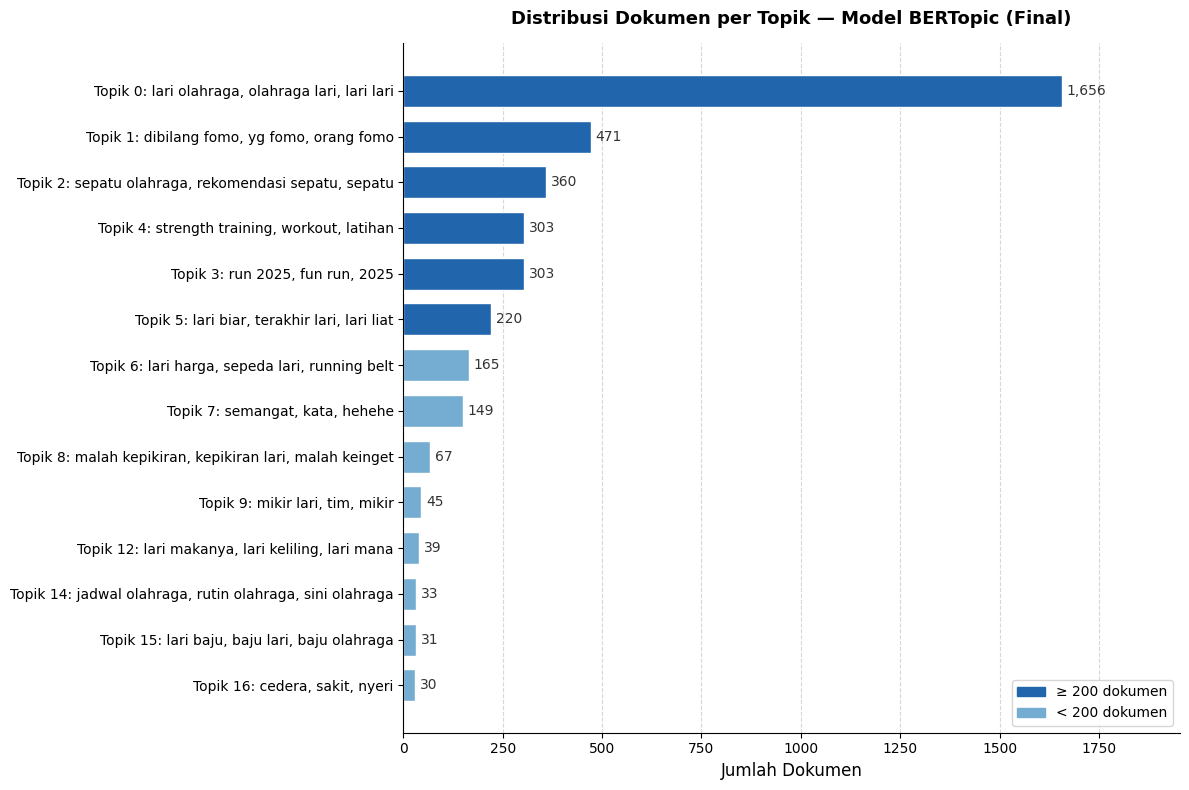

In [ ]:
# ════════════════════════════════════════════════════════════════
# GAMBAR 2 — Distribusi Dokumen per Topik (Final)
# Posisi skripsi: Setelah Tabel distribusi topik final
# ════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

# Topik noise yang dikecualikan (sesuai dengan notebook)
NOISE_TOPICS = [10, 11, 13, 17, 18]

# Ambil info topik dari model
topic_info_all = topic_model.get_topic_info()

# Filter: buang outlier (-1) dan topik noise
topic_info_plot = topic_info_all[
    (topic_info_all["Topic"] != -1) &
    (~topic_info_all["Topic"].isin(NOISE_TOPICS))
].copy()

# Buat label: "T0: lari olahraga, run, ..."
def make_label(topic_id, n=3):
    words = [w for w, _ in topic_model.get_topic(topic_id)[:n]]
    return f"Topik {topic_id}: {', '.join(words)}"

topic_info_plot["label"] = topic_info_plot["Topic"].apply(make_label)

# Urutkan descending berdasarkan jumlah dokumen
topic_info_plot = topic_info_plot.sort_values("Count", ascending=True)

counts = topic_info_plot["Count"].tolist()
labels = topic_info_plot["label"].tolist()

# Warna: biru tua untuk topik besar, biru muda untuk kecil
threshold_big = 200
colors = ["#2166AC" if c >= threshold_big else "#74ADD1" for c in counts]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(labels, counts, color=colors, edgecolor="white", height=0.7)

# Label angka di ujung bar
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 12, bar.get_y() + bar.get_height() / 2,
            f"{count:,}", va="center", ha="left", fontsize=10, color="#333333")

ax.set_xlabel("Jumlah Dokumen", fontsize=12)
ax.set_title("Distribusi Dokumen per Topik — Model BERTopic (Final)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlim(0, max(counts) * 1.18)
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=10)

# Legend warna
patch_big   = mpatches.Patch(color="#2166AC", label=f"≥ {threshold_big} dokumen")
patch_small = mpatches.Patch(color="#74ADD1", label=f"< {threshold_big} dokumen")
ax.legend(handles=[patch_big, patch_small], loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("gambar_distribusi_topik.png", dpi=300, bbox_inches="tight")
plt.show()

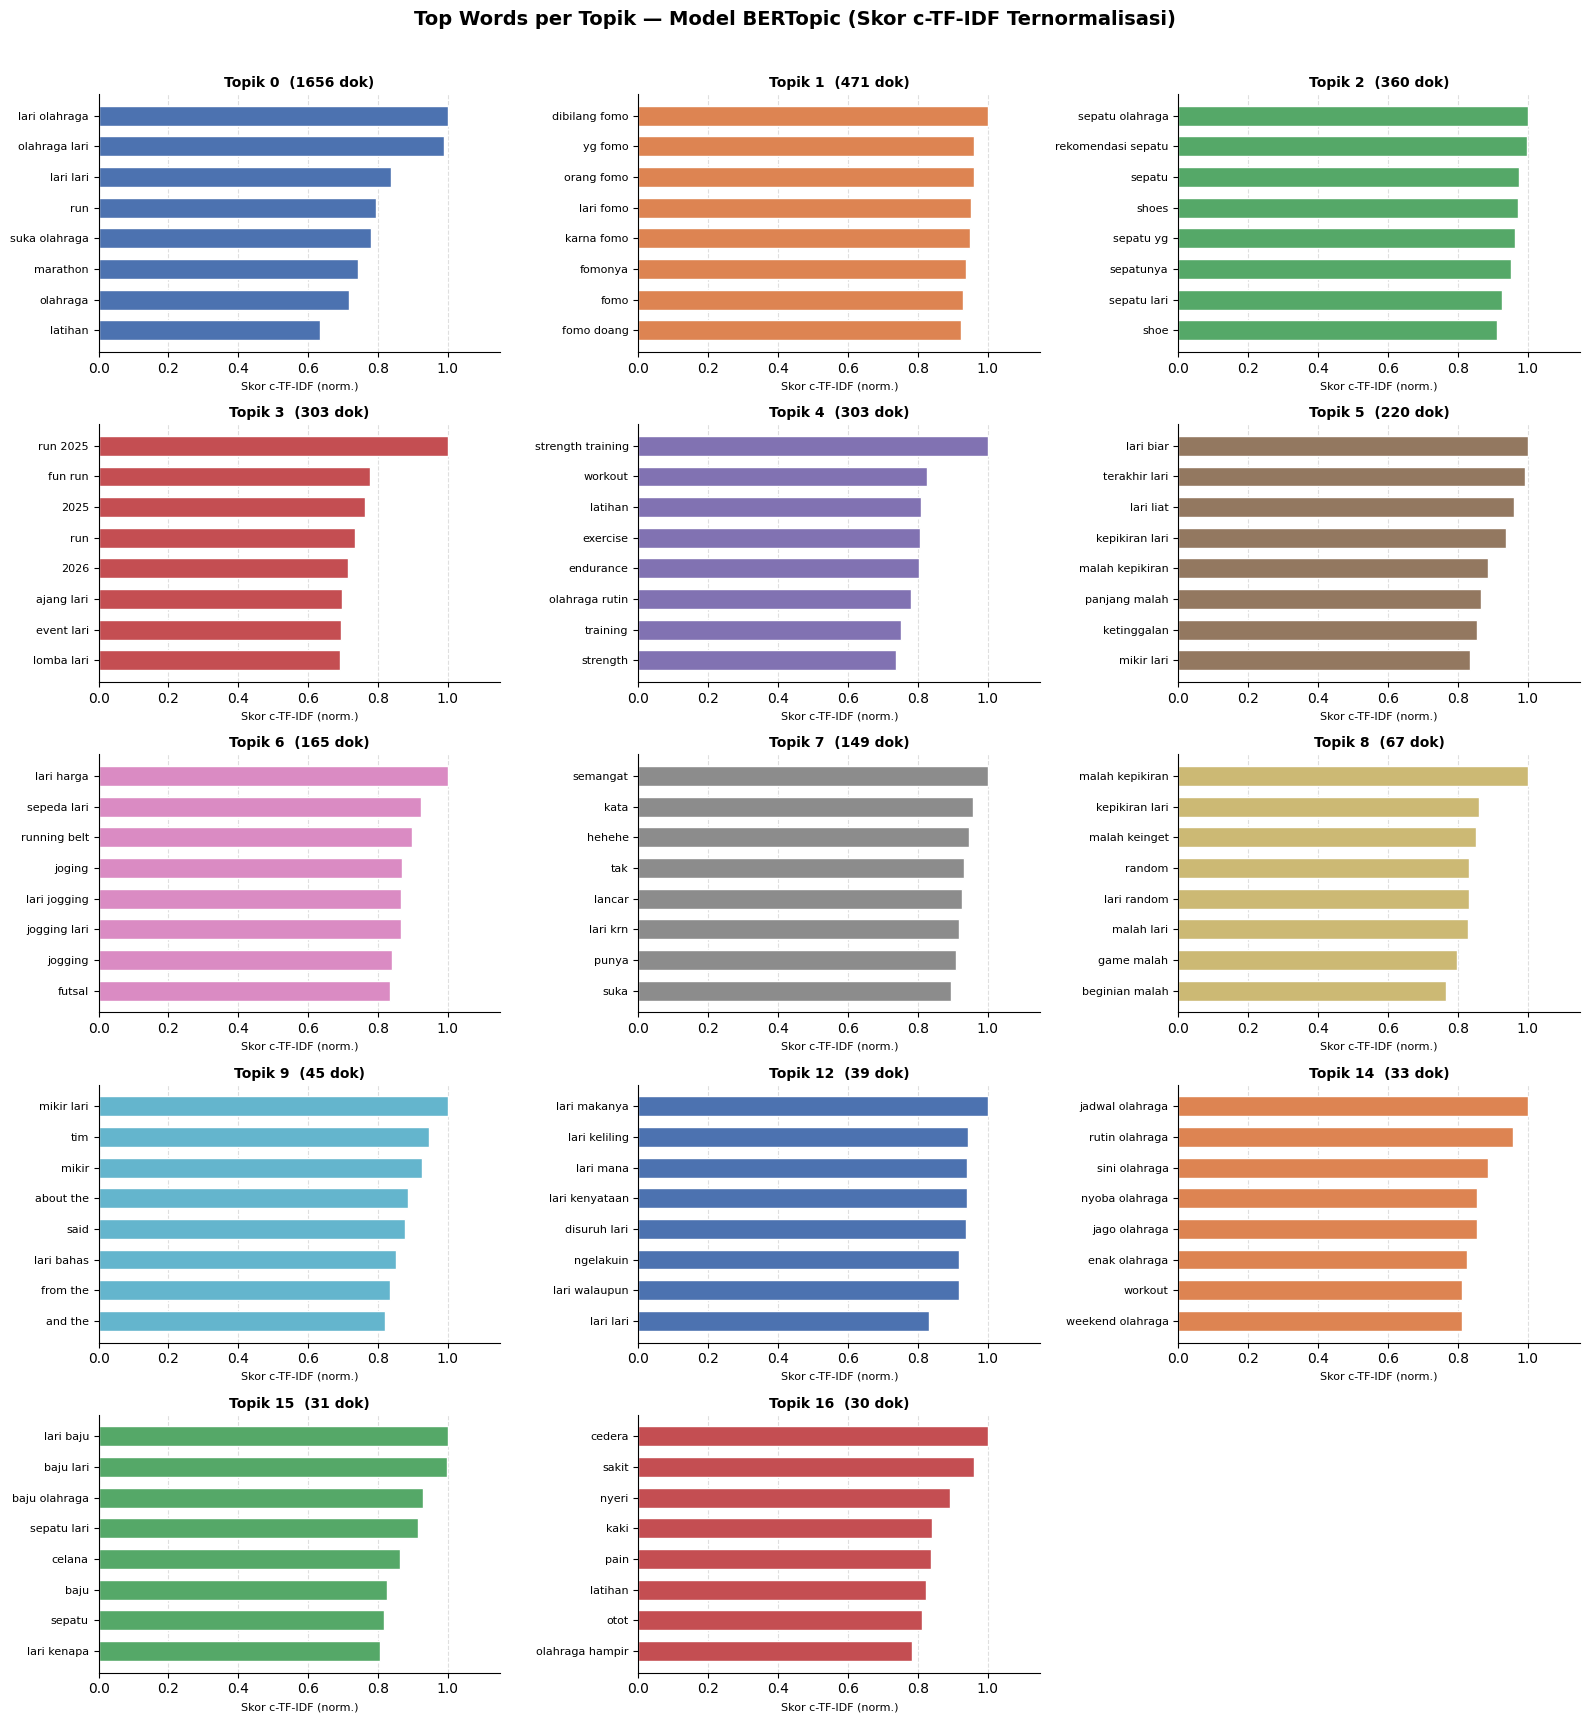

In [ ]:
# ════════════════════════════════════════════════════════════════
# GAMBAR 3 — Grid Bar Chart Top Words per Topik (c-TF-IDF)
# Posisi skripsi: Setelah narasi interpretasi topik
# ════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import math

NOISE_TOPICS = [10, 11, 13, 17, 18]
N_WORDS      = 8    # kata per topik yang ditampilkan
N_COLS       = 3

# Ambil valid_topic_ids dari notebook (atau rebuild di sini)
topic_info_all = topic_model.get_topic_info()
valid_topic_ids_plot = sorted([
    t for t in topic_info_all["Topic"].tolist()
    if t != -1 and t not in NOISE_TOPICS
])

N_TOPICS = len(valid_topic_ids_plot)
N_ROWS   = math.ceil(N_TOPICS / N_COLS)

PALETTE = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52",
    "#8172B2", "#937860", "#DA8BC3", "#8C8C8C",
    "#CCB974", "#64B5CD", "#4C72B0", "#DD8452",
    "#55A868", "#C44E52"
]

fig, axes = plt.subplots(N_ROWS, N_COLS,
                         figsize=(16, N_ROWS * 3.4))
axes = axes.flatten()

for idx, topic_id in enumerate(valid_topic_ids_plot):
    ax    = axes[idx]
    color = PALETTE[idx % len(PALETTE)]

    # Ambil top words dan skor c-TF-IDF dari model
    topic_words = topic_model.get_topic(topic_id)[:N_WORDS]
    words  = [w for w, _ in topic_words]
    scores = [s for _, s in topic_words]

    # Normalisasi skor ke 0–1 untuk perbandingan visual
    max_s  = max(scores) if max(scores) > 0 else 1
    scores_norm = [s / max_s for s in scores]

    # Plot horizontal (kata di bawah = skor tertinggi)
    ax.barh(words[::-1], scores_norm[::-1], color=color,
            edgecolor="white", height=0.65)

    # Judul panel
    topic_count = topic_info_all.loc[
        topic_info_all["Topic"] == topic_id, "Count"
    ].values[0]
    ax.set_title(f"Topik {topic_id}  ({topic_count} dok)",
                 fontsize=10, fontweight="bold", pad=5)
    ax.set_xlim(0, 1.15)
    ax.set_xlabel("Skor c-TF-IDF (norm.)", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

# Sembunyikan panel kosong (jika jumlah topik < N_ROWS*N_COLS)
for j in range(N_TOPICS, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Top Words per Topik — Model BERTopic (Skor c-TF-IDF Ternormalisasi)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("gambar_grid_topwords.png", dpi=300, bbox_inches="tight")
plt.show()

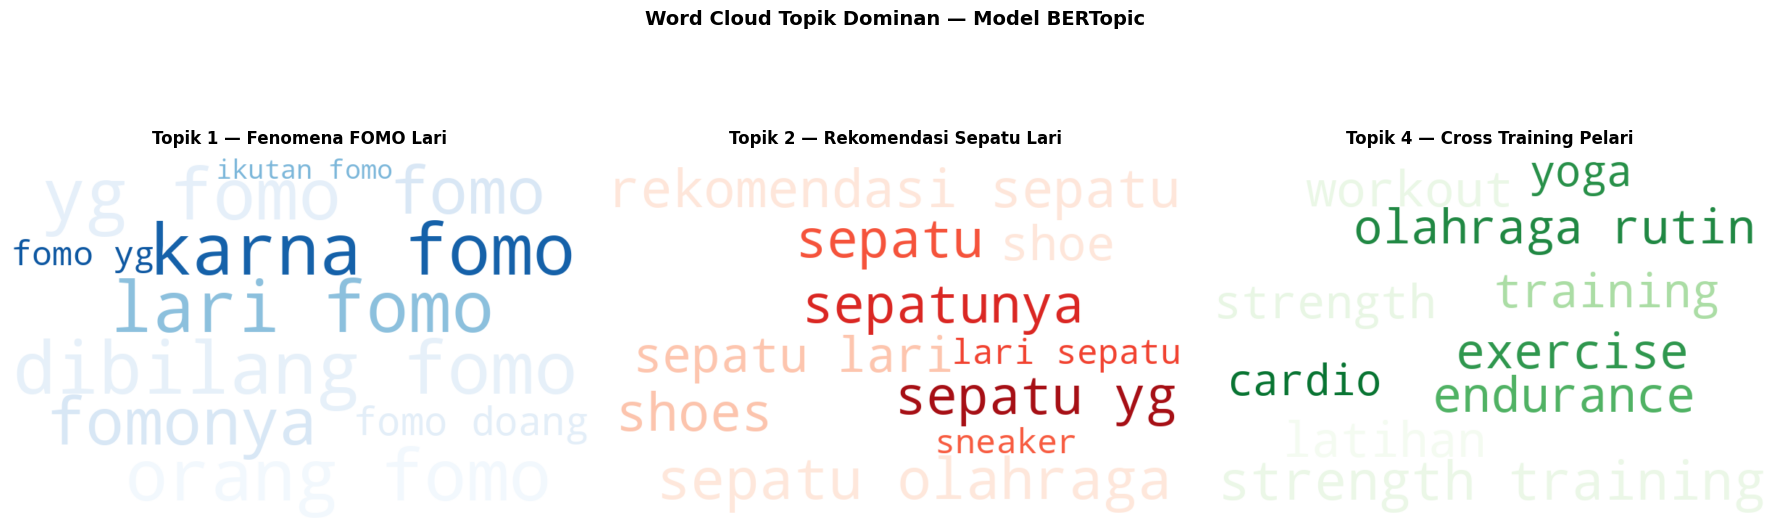

In [ ]:
# ════════════════════════════════════════════════════════════════
# GAMBAR 4 — Word Cloud Tiga Topik Dominan (0, 1, 3)
# Posisi skripsi: Setelah interpretasi masing-masing topik
# ════════════════════════════════════════════════════════════════

# Install wordcloud jika belum ada
# !pip install wordcloud   ← uncomment jika di Colab

from wordcloud import WordCloud
import matplotlib.pyplot as plt

TARGET_TOPICS = {
    1: "Topik 1 — Fenomena FOMO Lari",
    2: "Topik 2 — Rekomendasi Sepatu Lari",
    4: "Topik 4 — Cross Training Pelari"
}

CMAPS = {
    1: "Blues",
    2: "Reds",
    4: "Greens"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (topic_id, title) in zip(axes, TARGET_TOPICS.items()):
    # Ambil top-30 kata dan skor c-TF-IDF dari model
    topic_words = topic_model.get_topic(topic_id)[:30]

    # WordCloud menerima dict {word: weight}
    # Skor bisa negatif → ambil abs, min = 0.01 agar tidak hilang
    word_freq = {
        w: max(abs(s), 0.01)
        for w, s in topic_words
    }

    wc = WordCloud(
        width=800,
        height=500,
        background_color="white",
        colormap=CMAPS[topic_id],
        max_words=30,
        prefer_horizontal=0.85,
        random_state=42
    ).generate_from_frequencies(word_freq)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.axis("off")

fig.suptitle("Word Cloud Topik Dominan — Model BERTopic",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("word_cloud_dominanBERT.png", dpi=300, bbox_inches="tight")
plt.show()




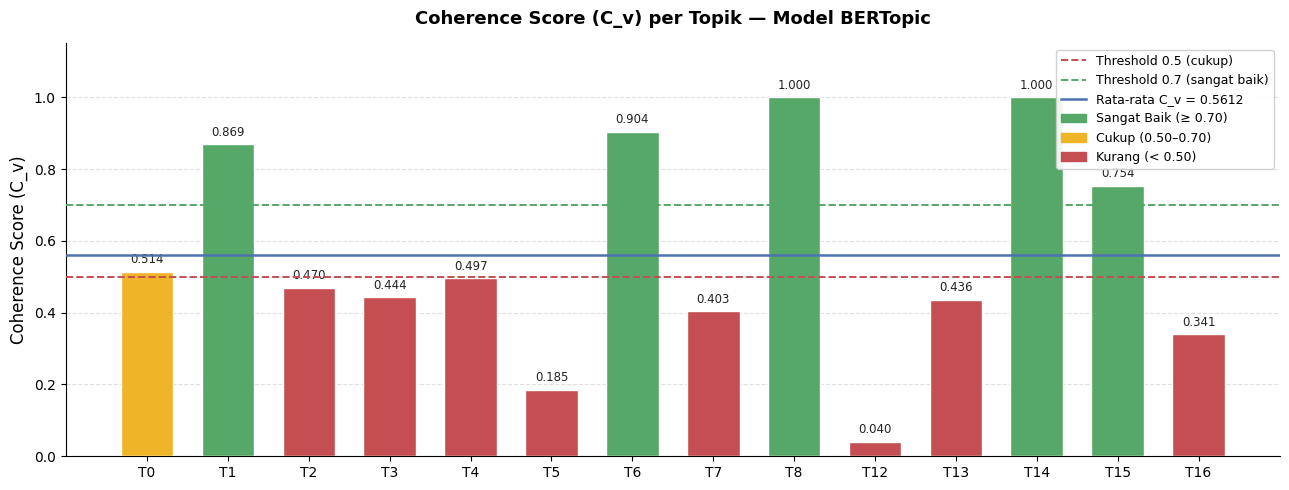

In [ ]:

# ════════════════════════════════════════════════════════════════
# GAMBAR 5 — Bar Chart Coherence Score per Topik
# Posisi skripsi: Setelah Tabel coherence C_v
# ════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Pastikan variabel ini tersedia dari Cell 33 notebook:
#   valid_topic_ids      → list topic ID yang valid
#   coherence_per_topic  → list nilai C_v per topik (urutan sama)
#   coherence_score      → rata-rata C_v

# Warna per bar berdasarkan kategori
def cv_color(val):
    if val >= 0.7:
        return "#55A868"   # hijau  → sangat baik
    elif val >= 0.5:
        return "#f0b429"   # kuning → cukup
    else:
        return "#C44E52"   # merah  → kurang

bar_colors_cv = [cv_color(v) for v in coherence_per_topic]
x_labels      = [f"T{t}" for t in valid_topic_ids]

fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.bar(x_labels, coherence_per_topic,
              color=bar_colors_cv, edgecolor="white", width=0.65, zorder=3)

# Nilai di atas bar
for bar, val in zip(bars, coherence_per_topic):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8.5, color="#222222")

# Garis threshold
ax.axhline(y=0.5, color="#C44E52", linestyle="--", linewidth=1.4,
           label="Threshold 0.5 (cukup)", zorder=4)
ax.axhline(y=0.7, color="#55A868", linestyle="--", linewidth=1.4,
           label="Threshold 0.7 (sangat baik)", zorder=4)

# Garis rata-rata
ax.axhline(y=coherence_score, color="#4C72B0", linestyle="-",
           linewidth=1.8, label=f"Rata-rata C_v = {coherence_score:.4f}",
           zorder=4)

ax.set_ylabel("Coherence Score (C_v)", fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title("Coherence Score (C_v) per Topik — Model BERTopic",
             fontsize=13, fontweight="bold", pad=14)
ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", labelsize=10)

# Legend warna kategori
p_green  = mpatches.Patch(color="#55A868", label="Sangat Baik (≥ 0.70)")
p_yellow = mpatches.Patch(color="#f0b429", label="Cukup (0.50–0.70)")
p_red    = mpatches.Patch(color="#C44E52", label="Kurang (< 0.50)")
handles_extra = [p_green, p_yellow, p_red]
handles_line, labels_line = ax.get_legend_handles_labels()
ax.legend(handles=handles_line + handles_extra,
          loc="upper right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("coherence_Score_perTopik", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════
# GAMBAR 6 — Intertopic Distance Map
# Posisi skripsi: Setelah Insight Analitis
# ════════════════════════════════════════════════════════════════

# Visualisasi interaktif menggunakan Plotly (bawaan BERTopic)
# Di Colab: tampil inline. Untuk skripsi: simpan HTML + screenshot.

fig_map = topic_model.visualize_topics()

fig_map.update_layout(
    title_text=(
        "Intertopic Distance Map — Model BERTopic<br>"
        "<sup>Ukuran lingkaran proporsional dengan jumlah dokumen | "
        "Jarak mencerminkan perbedaan konten antar topik</sup>"
    ),
    title_font_size=14,
    title_x=0.5,
    width=900,
    height=650
)

# Tampilkan inline di Colab
fig_map.show()

# Simpan sebagai file HTML interaktif
html_path = "gambar_intertopic_distance.html"
fig_map.write_html(html_path)
print(f"✅ Disimpan (HTML interaktif): {html_path}")
print("   → Buka di browser untuk visualisasi interaktif")
print()

# Export statis untuk PDF skripsi (membutuhkan kaleido)
# Jalankan terlebih dahulu: !pip install kaleido
try:
    png_path = "gambar_intertopic_distance.png"
    fig_map.write_image(png_path, scale=2)
    print(f"✅ Disimpan (PNG statis, 2x resolusi): {png_path}")
    print("   → Gunakan file ini untuk dimasukkan ke skripsi LaTeX/Word")
except Exception:
    print("⚠️  Export PNG gagal. Jalankan: !pip install kaleido")
    print("   Alternatif: Screenshot browser dari file HTML")
    print()
    print("   Cara screenshot di Colab:")
    print("   1. Jalankan: from IPython.display import IFrame")
    print(f"   2. Jalankan: IFrame('{html_path}', width=900, height=650)")
    print("   3. Screenshot output tersebut")

✅ Disimpan (HTML interaktif): gambar_intertopic_distance.html
   → Buka di browser untuk visualisasi interaktif

⚠️  Export PNG gagal. Jalankan: !pip install kaleido
   Alternatif: Screenshot browser dari file HTML

   Cara screenshot di Colab:
   1. Jalankan: from IPython.display import IFrame
   2. Jalankan: IFrame('gambar_intertopic_distance.html', width=900, height=650)
   3. Screenshot output tersebut
